In [1]:
from warnings import filterwarnings; filterwarnings("ignore")
import joblib
import pandas as pd
import numpy as np
import pandas, numpy
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import StackingRegressor

from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LassoLars

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:

class DataPreprocessing:
    def __init__(self, train, test):
        self.target = "ghi"
        self.column_drop = "timestamp"
        
        # Store original data with proper column handling
        self.train_original = train.copy()
        self.test_original = test.copy()
        
        # Handle unnamed columns and basic cleaning
        if 'Unnamed: 0' in train.columns:
            self.train = train.drop(columns=['Unnamed: 0'])
            self.test = test.drop(columns=['Unnamed: 0'])
        else:
            self.train = train.copy()
            self.test = test.copy()
        
        # Initial data cleaning - keep all rows for solar forecasting
        # Only drop rows where timestamp is missing (critical for time series)
        self.train = self.train.dropna(subset=['timestamp'])
        self.test = self.test.dropna(subset=['timestamp'])
        
        print(f"Training data shape: {self.train.shape}")
        print(f"Test data shape: {self.test.shape}")
        
        # Execute preprocessing pipeline
        self.feature_extraction()
        self.handle_solar_specific_features()
        self.handle_missing_values()
        self.train_test_split()
        self.normalise_encode()
        
    def feature_extraction(self):
        """Enhanced feature extraction for solar forecasting"""
        # Convert timestamp to datetime
        self.train['timestamp'] = pd.to_datetime(self.train['timestamp'])
        self.test['timestamp'] = pd.to_datetime(self.test['timestamp'])
        
        # Basic time features
        for df in [self.train, self.test]:
            df['timestamp_year'] = df['timestamp'].dt.year
            df['timestamp_month'] = df['timestamp'].dt.month
            df['timestamp_day'] = df['timestamp'].dt.day
            df['timestamp_hour'] = df['timestamp'].dt.hour
            df['timestamp_minute'] = df['timestamp'].dt.minute
            
            # Solar-specific temporal features
            df['day_of_year'] = df['timestamp'].dt.dayofyear
            df['week_of_year'] = df['timestamp'].dt.isocalendar().week
            df['day_of_week'] = df['timestamp'].dt.dayofweek
            
            # Cyclical encoding for periodic features
            df['hour_sin'] = np.sin(2 * np.pi * df['timestamp_hour'] / 24)
            df['hour_cos'] = np.cos(2 * np.pi * df['timestamp_hour'] / 24)
            df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
            df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
            df['month_sin'] = np.sin(2 * np.pi * df['timestamp_month'] / 12)
            df['month_cos'] = np.cos(2 * np.pi * df['timestamp_month'] / 12)
            
            # Season encoding (important for solar)
            df['season'] = ((df['timestamp_month'] % 12) // 3)
            
            # Solar elevation approximation (simplified)
            df['solar_elevation_approx'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25) * \
                                         np.sin(2 * np.pi * df['timestamp_hour'] / 24)
        
        print("Feature extraction completed")
    
    def handle_solar_specific_features(self):
        """Handle solar-specific feature engineering"""
        for df in [self.train, self.test]:
            # Clear sky conditions indicator
            if 'relative_humidity' in df.columns and 'wind_speed' in df.columns:
                df['clear_sky_indicator'] = (100 - df['relative_humidity']) * df['wind_speed'] / 100
            
            # Temperature differential (important for solar panels)
            module_temp_cols = [col for col in df.columns if 'module_temperature' in col]
            if module_temp_cols and 'ambient_temperature' in df.columns:
                df['temp_differential'] = df[module_temp_cols].mean(axis=1) - df['ambient_temperature']
            
            # Radiation ratios (useful for cloud detection)
            if 'irradiance_horizontal' in df.columns and 'irradiance_global_reference' in df.columns:
                df['radiation_ratio'] = df['irradiance_horizontal'] / (df['irradiance_global_reference'] + 1e-6)
            
            # Wind direction encoding (cyclical)
            if 'wind_direction' in df.columns:
                df['wind_dir_sin'] = np.sin(2 * np.pi * df['wind_direction'] / 360)
                df['wind_dir_cos'] = np.cos(2 * np.pi * df['wind_direction'] / 360)
            
            # Aggregate radiation features
            horizontal_rad_cols = [col for col in df.columns if 'horizontal_radiation' in col]
            incident_rad_cols = [col for col in df.columns if 'incident_radiation' in col]
            reflected_rad_cols = [col for col in df.columns if 'reflected_radiation' in col]
            
            if horizontal_rad_cols:
                df['horizontal_radiation_mean'] = df[horizontal_rad_cols].mean(axis=1)
                df['horizontal_radiation_std'] = df[horizontal_rad_cols].std(axis=1).fillna(0)
            
            if incident_rad_cols:
                df['incident_radiation_mean'] = df[incident_rad_cols].mean(axis=1)
                df['incident_radiation_std'] = df[incident_rad_cols].std(axis=1).fillna(0)
            
            if reflected_rad_cols:
                df['reflected_radiation_mean'] = df[reflected_rad_cols].mean(axis=1)
        
        print("Solar-specific feature engineering completed")
    
    def handle_missing_values(self):
        """Intelligent missing value handling for solar data"""
        # For GHI target variable, use forward/backward fill (solar follows patterns)
        self.train[self.target] = self.train[self.target].ffill().bfill().fillna(0)
        self.test[self.target] = self.test[self.target].ffill().bfill().fillna(0)
        
        # For radiation features, nighttime should be 0
        radiation_cols = [col for col in self.train.columns if 'radiation' in col or 'irradiance' in col]
        
        for df in [self.train, self.test]:
            # Set nighttime radiation to 0 (between 6 PM and 6 AM)
            night_mask = (df['timestamp_hour'] >= 18) | (df['timestamp_hour'] <= 6)
            
            for col in radiation_cols:
                if col in df.columns:
                    df.loc[night_mask, col] = df.loc[night_mask, col].fillna(0)
                    # For daytime, use linear interpolation
                    df[col] = df[col].interpolate(method='linear').ffill().bfill()
        
        # For other meteorological features, use seasonal means
        for df in [self.train, self.test]:
            for col in df.columns:
                if col not in ['timestamp', self.target] and df[col].dtype in ['float64', 'int64']:
                    if df[col].isnull().sum() > 0:
                        # Fill with seasonal means
                        seasonal_means = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('mean')
                        df[col] = df[col].fillna(seasonal_means)
                        # Fallback to overall mean
                        df[col] = df[col].fillna(df[col].mean())
        
        print("Missing value handling completed")
    
    def train_test_split(self):
        """Split features and target"""
        # Store timestamp for later use
        self.train_timestamps = self.train['timestamp'].copy()
        self.test_timestamps = self.test['timestamp'].copy()
        
        # Prepare features and target
        columns_to_drop = [self.target, 'timestamp']
        
        self.train_x = self.train.drop(columns=columns_to_drop)
        self.train_y = self.train[self.target]
        
        self.test_x = self.test.drop(columns=columns_to_drop)
        self.test_y = self.test[self.target]
        
        print(f"Features shape - Train: {self.train_x.shape}, Test: {self.test_x.shape}")
        print(f"Target shape - Train: {self.train_y.shape}, Test: {self.test_y.shape}")
    
    def normalise_encode(self):
        """Enhanced normalization and encoding"""
        # Initialize scalers
        self.scaler = StandardScaler()
        self.label_encoders = {}
        
        # Separate categorical and numerical columns
        categorical_cols = self.train_x.select_dtypes(include=['object']).columns
        numerical_cols = self.train_x.select_dtypes(include=[np.number]).columns
        
        # Handle categorical columns
        for col in categorical_cols:
            le = LabelEncoder()
            
            # Fit on combined data to handle unseen categories
            combined_data = pd.concat([self.train_x[col], self.test_x[col]]).fillna('Unknown').astype(str)
            le.fit(combined_data)
            
            self.train_x[col] = le.transform(self.train_x[col].fillna('Unknown').astype(str))
            self.test_x[col] = le.transform(self.test_x[col].fillna('Unknown').astype(str))
            
            self.label_encoders[col] = le
        
        # Handle numerical columns with StandardScaler
        if len(numerical_cols) > 0:
            self.train_x[numerical_cols] = self.scaler.fit_transform(self.train_x[numerical_cols])
            self.test_x[numerical_cols] = self.scaler.transform(self.test_x[numerical_cols])
        
        print(f"Normalization completed. Features: {list(self.train_x.columns)}")
        
    def get_feature_importance_info(self):
        """Return information about created features"""
        feature_info = {
            'temporal_features': ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos'],
            'solar_features': ['solar_elevation_approx', 'clear_sky_indicator', 'temp_differential'],
            'aggregated_features': ['horizontal_radiation_mean', 'incident_radiation_mean', 'reflected_radiation_mean'],
            'original_features': [col for col in self.train_x.columns if not any(
                f in col for f in ['_sin', '_cos', '_mean', '_std', 'clear_sky', 'temp_differential', 'radiation_ratio']
            )]
        }
        return feature_info
    
    def get_data_summary(self):
        """Return summary of preprocessing results"""
        summary = {
            'train_samples': len(self.train_x),
            'test_samples': len(self.test_x),
            'n_features': self.train_x.shape[1],
            'target_range_train': (self.train_y.min(), self.train_y.max()),
            'target_range_test': (self.test_y.min(), self.test_y.max()),
            'missing_values_train': self.train_x.isnull().sum().sum(),
            'missing_values_test': self.test_x.isnull().sum().sum(),
        }
        return summary

In [3]:
train = pandas.read_csv("/kaggle/input/zelestra-energy-data/Train Dataset.csv")
test = pandas.read_csv("/kaggle/input/zelestra-energy-data/Test Dataset.csv")

data = DataPreprocessing(train, test)
train_x = data.train_x
train_y = data.train_y
test_x = data.test_x
test_y = data.test_y

Training data shape: (2182, 22)
Test data shape: (1392, 22)
Feature extraction completed
Solar-specific feature engineering completed
Missing value handling completed
Features shape - Train: (2182, 46), Test: (1392, 46)
Target shape - Train: (2182,), Test: (1392,)
Normalization completed. Features: ['irradiance_global_reference', 'irradiance_horizontal', 'module_temperature_1', 'module_temperature_2', 'module_temperature_3', 'wind_direction', 'relative_humidity', 'horizontal_radiation_1', 'horizontal_radiation_2', 'horizontal_radiation_3', 'incident_radiation_1', 'incident_radiation_2', 'incident_radiation_4', 'incident_radiation_3', 'reflected_radiation_1', 'reflected_radiation_2', 'reflected_radiation_4', 'reflected_radiation_3', 'ambient_temperature', 'wind_speed', 'timestamp_year', 'timestamp_month', 'timestamp_day', 'timestamp_hour', 'timestamp_minute', 'day_of_year', 'week_of_year', 'day_of_week', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'season', '

In [4]:
train_x

,irradiance_global_reference,irradiance_horizontal,module_temperature_1,module_temperature_2,module_temperature_3,wind_direction,relative_humidity,horizontal_radiation_1,horizontal_radiation_2,horizontal_radiation_3,...,clear_sky_indicator,temp_differential,radiation_ratio,wind_dir_sin,wind_dir_cos,horizontal_radiation_mean,horizontal_radiation_std,incident_radiation_mean,incident_radiation_std,reflected_radiation_mean
0,-0.779606,-0.021413,-0.945310,-0.997840,-0.031387,-0.072242,0.704156,-0.695361,0.0,-0.063766,...,-0.620365,-0.256976,-0.021413,0.166609,-0.620096,-0.021413,-0.021413,-0.726472,-0.537394,-0.760045
1,-0.779606,-0.021413,-0.966456,-1.023701,-0.037906,1.831933,0.704111,-0.695361,0.0,-0.063766,...,-0.620365,-0.258128,-0.021413,-2.057248,1.228321,-0.021413,-0.021413,-0.726472,-0.537394,-0.760045
2,-0.779606,-0.021413,-0.910516,-0.948391,-0.019714,0.894201,0.704146,-0.695361,0.0,-0.063766,...,-0.620365,-0.215752,-0.021413,-1.253154,-0.301591,-0.021413,-0.021413,-0.726472,-0.537394,-0.760045
3,-0.779606,-0.021413,-0.897581,-0.927347,-0.015251,-0.251909,0.704122,-0.695361,0.0,-0.063766,...,-0.620243,-0.207034,-0.021413,0.428202,-0.507941,-0.021413,-0.021413,-0.726472,-0.537394,-0.760045
4,-0.779606,-0.021413,-0.856050,-0.894759,-0.005059,-0.580335,0.704183,-0.695361,0.0,-0.063766,...,-0.620365,-0.190179,-0.021413,0.862602,-0.174156,-0.021413,-0.021413,-0.726472,-0.537394,-0.760045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2177,-0.779606,-0.021413,-0.733517,-0.676686,-5.148269,0.465320,0.665052,-0.695361,0.0,-0.063766,...,-0.600401,-4.645254,-0.021413,-0.649243,-0.633278,-0.021413,-0.021413,-0.726472,-0.537394,-0.760045
2178,-0.779606,-0.021413,-0.785808,-0.730854,-5.126093,0.294082,0.665375,-0.695361,0.0,-0.063766,...,-0.596892,-4.619056,-0.021413,-0.389954,-0.682213,-0.021413,-0.021413,-0.726472,-0.537394,-0.760045
2179,-0.779606,-0.021413,-0.796750,-0.762978,-5.160410,0.468146,0.680276,-0.695361,0.0,-0.063766,...,-0.604235,-4.655181,-0.021413,-0.653471,-0.632058,-0.021413,-0.021413,-0.726472,-0.537394,-0.760045
2180,-0.779606,-0.021413,-0.835254,-0.743818,-5.195768,0.260194,0.704264,-0.695361,0.0,-0.063766,...,-0.620282,-4.661854,-0.021413,-0.338168,-0.686021,-0.021413,-0.021413,-0.726472,-0.537394,-0.760045


In [5]:
class solo_models:
    def __new__(self, train_X, train_y):
        print('INITIATING PARAMETER')
        self.X_train, self.y_train = train_X, train_y
        
        self.LGBM_R_parm = {'colsample_bytree': 0.7988997727163004,
                            'drop_rate': 0.2968017716958511,
                            'learning_rate': 0.17403795838781744,
                            'max_bin': 2707,
                            'max_depth': 9680,
                            'max_drop': 4736,
                            'min_child_samples': 7173,
                            'min_data_in_leaf': 458,
                            'n_estimators': 1655,
                            'num_leaves': 2755,
                            'objective': 'regression_l1',
                            'reg_alpha': 0.965759263160616,
                            'reg_lambda': 0.9274407181952318,
                            'skip_drop': 0.37396662816136594,
                            'verbosity': -1}
        
        self.XGB_R_parm = {'colsample_bytree': 0,
                           'gamma': 5,
                           'learning_rate': 0.18348831817680378,
                           'max_depth': 15,
                           'min_child_weight': 1,
                           'n_estimators': 13225,
                           'objective': 'reg:squarederror',
                           'reg_alpha': 94,
                           'reg_lambda': 0.41318910368801975,
                           'subsample': 0.5444965693077323}

        self.catboost_params = {'iterations' : 3000,
                                'learning_rate': 0.009, 
                                'depth': 5, 
                                'l2_leaf_reg': 5.5,
                                'min_child_samples' : 102,
                                'od_wait' : 50,
                                'random_state' : 42,
                                'eval_metric': 'RMSE', 
                                'od_type' : 'Iter',
                                'bootstrap_type': 'Bayesian', 
                                'grow_policy' : 'Depthwise',
                                'logging_level' : 'Silent'}

        self.R_Forest_parm = {'n_estimators' : 25, 
                              'min_samples_split' : 2, 
                              'max_depth' : 10, 
                              'min_samples_leaf' : 2, 
                              'random_state' : 42}
        
        self.Extra_parm = {'n_estimators' : 50, 
                           'min_samples_split' : 2, 
                           'max_depth' : 8, 
                           'min_samples_leaf' : 2, 
                           'random_state' : 42}
        
        self.GB_params = {'learning_rate' : 0.1, 
                          'min_samples_split' : 500,
                          'min_samples_leaf' : 50,
                          'max_depth' : 8,
                          'max_features' : 'sqrt',
                          'subsample' : 0.8,
                          'random_state' : 10}
        
        self.models(self)
        model_final = self.stack_training(self)
        return model_final

    def models(self):
        print('LOADING MODEL')
        self.model_collecter = {}
        
        self.model_collecter['LGBMRegressor'] = LGBMRegressor(**self.LGBM_R_parm)
        self.model_collecter['XGBRegressor'] = XGBRegressor(**self.XGB_R_parm)
        self.model_collecter['CatBoostRegressor'] = CatBoostRegressor(**self.catboost_params)

        self.model_collecter['random_forest'] = RandomForestRegressor(**self.R_Forest_parm)
        self.model_collecter['extra_trees'] = ExtraTreesRegressor(**self.Extra_parm)
        self.model_collecter['GradientBoostingRegressor'] = GradientBoostingRegressor(**self.GB_params)
        
    def stack_training(self):    
        print('--STACK')
        self.stack_model_1 = ['LGBMRegressor',
                              'XGBRegressor',
                              'CatBoostRegressor']
        self.stack_model_2 = ['random_forest',
                              'extra_trees',
                              'GradientBoostingRegressor']
        
        estimators_1 = [(i, self.model_collecter[i]) for i in self.stack_model_1]
        estimators_2 = [(i, self.model_collecter[i]) for i in self.stack_model_2]
        
        self.model_0 = StackingRegressor(list(self.model_collecter.items()), final_estimator = ElasticNetCV())
        self.model_1 = StackingRegressor(estimators_1, final_estimator = RidgeCV())
        self.model_2 = StackingRegressor(estimators_2, final_estimator = LassoLars())

        estimators_3 = [('STACK_model_1', self.model_1),('STACK_model_2', self.model_2)]
        self.model_3 = StackingRegressor(estimators_3, final_estimator = LassoCV())
        
        estimators_final = [('STACK_model_0', self.model_0),('STACK_model_3', self.model_3)]
        self.model_final = StackingRegressor(estimators_final, final_estimator = RidgeCV())
        self.model_final.fit(self.X_train, self.y_train)
        
        return self.model_final

In [6]:
class score_compiler:
    def __new__(self, model, test_x, test_y):
        self.model = model
        self.X_test, self.y_test = test_x, test_y
        return self.loss_Calculation(self)
        
    def loss_Calculation(self):
        y_pred, mape_loss = self.model.predict(self.X_test), []
        total_loss = mean_absolute_percentage_error(y_pred, self.y_test)
        for actual, predected in zip(y_pred, self.y_test):
            mape_loss.append(mean_absolute_percentage_error([predected], [actual]))
        return y_pred, numpy.array(mape_loss), total_loss

In [7]:
model_final = solo_models(train_x, train_y)
joblib.dump(model_final, f'model_final.pkl')

INITIATING PARAMETER
LOADING MODEL
--STACK


['model_final.pkl']

In [8]:
model_final

StackingRegressor(estimators=[('STACK_model_0',
                               StackingRegressor(estimators=[('LGBMRegressor',
                                                              LGBMRegressor(colsample_bytree=0.7988997727163004,
                                                                            drop_rate=0.2968017716958511,
                                                                            learning_rate=0.17403795838781744,
                                                                            max_bin=2707,
                                                                            max_depth=9680,
                                                                            max_drop=4736,
                                                                            min_child_samples=7173,
                                                                            min_data_in_leaf=458,
                                                                            n_estimators=1655,
                                                                            num_leaves=2755,
                                                                            objective='regression_l...
                                                                                                                   random_state=42)),
                                                                                            ('extra_trees',
                                                                                             ExtraTreesRegressor(max_depth=8,
                                                                                                                 min_samples_leaf=2,
                                                                                                                 n_estimators=50,
                                                                                                                 random_state=42)),
                                                                                            ('GradientBoostingRegressor',
                                                                                             GradientBoostingRegressor(max_depth=8,
                                                                                                                       max_features='sqrt',
                                                                                                                       min_samples_leaf=50,
                                                                                                                       min_samples_split=500,
                                                                                                                       random_state=10,
                                                                                                                       subsample=0.8))],
                                                                                final_estimator=LassoLars()))],
                                                 final_estimator=LassoCV()))],
                  final_estimator=RidgeCV())

In [9]:
y_pred, mape_loss, total_loss = score_compiler(model_final, test_x, test_y)

In [10]:
total_loss

0.7456228925797231

In [11]:
len(y_pred), len(test_y)

(1392, 1392)

In [12]:
pandas.DataFrame({"predict" : y_pred}), test_y

(       predict
 0    -5.329480
 1    -5.354897
 2    -5.584441
 3    -5.314664
 4    -5.336316
 ...        ...
 1387  1.246736
 1388 -3.125198
 1389 -1.242922
 1390 -2.019296
 1391 -0.188561
 
 [1392 rows x 1 columns],
 0       0.0
 1       0.0
 2       0.0
 3       0.0
 4       0.0
        ... 
 1387    0.0
 1388    0.0
 1389    0.0
 1390    0.0
 1391    0.0
 Name: ghi, Length: 1392, dtype: float64)

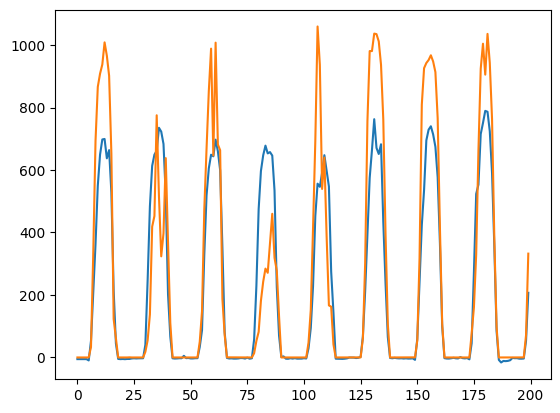

In [13]:
plt.plot(y_pred[:200])
plt.plot(test_y.to_numpy()[:200])